# GraphSAGE 


In [1]:
import warnings, sys, gc, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
PROJECT_ROOT = Path().resolve()
GNN_DATA_PATH = PROJECT_ROOT / 'data' / 'df_gnn.parquet'
ML_DATA_PATH = PROJECT_ROOT / 'data' / 'df_split_model_RF_new_features.parquet'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'gnn' / 'ds1'
FIGURES_DIR = PROJECT_ROOT / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
HIDDEN_DIM = 64
DROPOUT = 0.3
LEARNING_RATE = 0.001
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 15
BETA = 2.0
FORCE_RETRAIN = True
SPLIT_MODE = 'tabular_y_v2'
print(f'OUTPUT_DIR:    {OUTPUT_DIR}')
print(f'FORCE_RETRAIN: {FORCE_RETRAIN}')


OUTPUT_DIR:    /Users/bolotnikovali/ИПС/outputs/gnn/ds1
FORCE_RETRAIN: True


In [2]:
import torch
print(f"torch: {torch.__version__}  device: {('cuda' if torch.cuda.is_available() else 'cpu')}")


torch: 2.11.0  device: cpu


## 1. Загрузка данных

In [3]:
sys.path.insert(0, str(PROJECT_ROOT))
from antifraud_pipeline.antifraud_lib import FeatureEngineer, rename_columns_drop_market
print('Загружаем ML-датасет...')
df_ml = pd.read_parquet(ML_DATA_PATH)
print(f"  df_ml: {df_ml.shape}  fraud_rate={df_ml['fraud_flg'].mean():.2%}")
fe = FeatureEngineer()
df = fe.fit_transform(df_ml)
df = rename_columns_drop_market(df)
del df_ml
gc.collect()
print(f'  После FE+rename: {df.shape}')
import pyarrow.parquet as pq
ENTITY_COLS = ['card_id', 'device_id', 'cookie', 'delivery_phone', 'user_phone', 'puid', 'crypta_id', 'delivery_address_ids', 'ip', 'ip_isp', 'phone_hash']
_gnn_cols = set(pq.read_schema(GNN_DATA_PATH).names)
_need = [c for c in ENTITY_COLS if c not in df.columns and c in _gnn_cols]
if _need:
    _ent = pd.read_parquet(GNN_DATA_PATH, columns=['order_id'] + _need)
    df = df.merge(_ent, on='order_id', how='left')
    del _ent
    gc.collect()
entity_cols = [c for c in ENTITY_COLS if c in df.columns]
print(f'  Entity-колонки: {entity_cols}')
print(f'\nИтого: {df.shape}')


Загружаем ML-датасет...
  df_ml: (4215398, 61)  fraud_rate=7.54%
  Парсинг временных признаков...
  Создание отношений (ratio features)...
  Создание возрастных признаков...
  Создание velocity-признаков...
  Создание флагов аномалий...

  Всего создано новых признаков: 32
  После FE+rename: (4215398, 94)
  Entity-колонки: ['card_id', 'device_id', 'cookie', 'delivery_phone', 'user_phone', 'puid', 'crypta_id', 'delivery_address_ids', 'ip', 'ip_isp']

Итого: (4215398, 104)


## 2. Построение графа

In [4]:
from antifraud_components.models.gnn import build_graph_data
TARGET_COL = 'fraud_flg'
_labeled = df[df[TARGET_COL].notna()].copy()
if 'order_creation_dttm' in _labeled.columns:
    _labeled = _labeled.sort_values('order_creation_dttm')
_n = len(_labeled)
train_oids = _labeled['order_id'].iloc[:int(_n * 0.65)].values
val_oids = _labeled['order_id'].iloc[int(_n * 0.65):int(_n * 0.8)].values
test_oids = _labeled['order_id'].iloc[int(_n * 0.8):].values
del _labeled
print(f'Сплит: train={len(train_oids):,}  val={len(val_oids):,}  test={len(test_oids):,}')
print(f'Fraud rate: {df[TARGET_COL].mean():.2%}')
print('\nСтроим граф (~5-10 мин)...')
data, scaler, feature_cols, order_ids = build_graph_data(df, entity_cols=entity_cols, id_col='order_id', target_col=TARGET_COL, train_order_ids=train_oids, val_order_ids=val_oids, test_order_ids=test_oids)
del df
gc.collect()
print(f'\nГраф: {data.num_nodes:,} узлов | {data.num_edges:,} рёбер | {len(feature_cols)} признаков')
print(f'train={data.train_mask.sum():,}  val={data.val_mask.sum():,}  test={data.test_mask.sum():,}')


Сплит: train=15,240  val=3,517  test=4,690
Fraud rate: 7.54%

Строим граф (~5-10 мин)...

=== GNN feature_cols (87 признаков) ===
    1. npv_37_day_with_compensation
    2. order_loan
    3. cookie_age
    4. card_age
    5. phone_age
    6. password_age
    7. puid_age
    8. puid_days_since_login_id_creation
    9. months_sum
   10. puid_card_age
   11. cart_item_category_fp_risk_category
   12. delivery_days
   13. glue_size
   14. glue_ead
   15. puid_card_ids_count
   16. cnt_split_paid
   17. sum_split_paid
   18. puid_months_with
   19. puid_months_with_taxiuber
   20. puid_days_since_first_transaction
   21. ml_limits_score_raw
   22. score
   23. mfm_score
   24. puid_orders_1h_without_refunds
   25. puid_orders_24h_without_refunds
   26. puid_orders_2d_without_refunds
   27. debt_on_card_id
   28. debt_on_cookie
   29. debt_on_crypta_id
   30. debt_on_delivery_phone
   31. debt_on_device_id
   32. debt_on_phone
   33. first_order_flg
   34. i_puid_karma
   35. i_browser_is_mo

## 3. Обучение

In [5]:
import importlib
import antifraud_components.models.gnn as _gnn_mod
importlib.reload(_gnn_mod)
from antifraud_components.models.gnn import train_gnn
if FORCE_RETRAIN:
    for f in ['best_model.pt', 'gnn_meta.json']:
        p = OUTPUT_DIR / f
        if p.exists():
            p.unlink()
            print(f'  Удалён старый чекпойнт: {p}')
model, history = train_gnn(data, in_channels=len(feature_cols), hidden=HIDDEN_DIM, dropout=DROPOUT, lr=LEARNING_RATE, epochs=EPOCHS, early_stopping_patience=EARLY_STOPPING_PATIENCE, output_dir=OUTPUT_DIR, feature_cols=feature_cols, skip_if_checkpoint=not FORCE_RETRAIN, split_mode=SPLIT_MODE)
np.save(OUTPUT_DIR / 'gnn_order_ids.npy', order_ids, allow_pickle=True)
print(f"\nOrder IDs сохранены: {OUTPUT_DIR / 'gnn_order_ids.npy'}")


Epoch   1 | loss=1.3210 | val F_β=0.2480 | val PR-AUC=0.0531
Epoch   2 | loss=1.0415 | val F_β=0.2586 | val PR-AUC=0.0709
Epoch   3 | loss=0.8452 | val F_β=0.2885 | val PR-AUC=0.1043
Epoch   4 | loss=0.7274 | val F_β=0.3473 | val PR-AUC=0.1654
Epoch   5 | loss=0.6425 | val F_β=0.4181 | val PR-AUC=0.2298
Epoch   6 | loss=0.6040 | val F_β=0.4513 | val PR-AUC=0.2887
Epoch   7 | loss=0.5774 | val F_β=0.4850 | val PR-AUC=0.3286
Epoch   8 | loss=0.5561 | val F_β=0.4997 | val PR-AUC=0.3556
Epoch   9 | loss=0.5411 | val F_β=0.5125 | val PR-AUC=0.3731
Epoch  10 | loss=0.5302 | val F_β=0.5249 | val PR-AUC=0.3838
Epoch  11 | loss=0.5216 | val F_β=0.5330 | val PR-AUC=0.3878
Epoch  12 | loss=0.5135 | val F_β=0.5385 | val PR-AUC=0.3904
Epoch  13 | loss=0.4974 | val F_β=0.5463 | val PR-AUC=0.3898
Epoch  14 | loss=0.4902 | val F_β=0.5533 | val PR-AUC=0.3898
Epoch  15 | loss=0.4783 | val F_β=0.5605 | val PR-AUC=0.3879
Epoch  16 | loss=0.4661 | val F_β=0.5625 | val PR-AUC=0.3869
Epoch  17 | loss=0.4599 

## 4. Оценка на тесте

In [6]:
from sklearn.metrics import average_precision_score, roc_auc_score, fbeta_score, classification_report
from antifraud_components.models.gnn import gnn_predict
probs_all = gnn_predict(model, data)
val_y = data.y[data.val_mask].cpu().numpy()
val_prob = probs_all[data.val_mask.cpu().numpy()]
test_y = data.y[data.test_mask].cpu().numpy()
test_prob = probs_all[data.test_mask.cpu().numpy()]
best_th, best_fbv = (0.5, -1.0)
for th in np.arange(0.01, 0.99, 0.01):
    fb = fbeta_score(val_y, (val_prob >= th).astype(int), beta=BETA, zero_division=0)
    if fb > best_fbv:
        best_fbv, best_th = (fb, float(th))
print('=' * 55)
print(f'TEST  GraphSAGE ds1  (порог по val Fβ = {best_th:.2f})')
print('=' * 55)
print(f'F_β (β={BETA}):  {fbeta_score(test_y, (test_prob >= best_th).astype(int), beta=BETA, zero_division=0):.4f}')
print(f'PR-AUC:         {average_precision_score(test_y, test_prob):.4f}')
print(f'ROC-AUC:        {roc_auc_score(test_y, test_prob):.4f}')
print(f'val Fβ:         {best_fbv:.4f}')
print()
print(classification_report(test_y, (test_prob >= best_th).astype(int), target_names=['non-fraud', 'fraud']))


TEST  GraphSAGE ds1  (порог по val Fβ = 0.68)
F_β (β=2.0):  0.4976
PR-AUC:         0.3248
ROC-AUC:        0.8706
val Fβ:         0.5763

              precision    recall  f1-score   support

   non-fraud       0.98      0.85      0.91      4421
       fraud       0.23      0.71      0.34       269

    accuracy                           0.85      4690
   macro avg       0.60      0.78      0.63      4690
weighted avg       0.94      0.85      0.88      4690



## 5. Кривые обучения

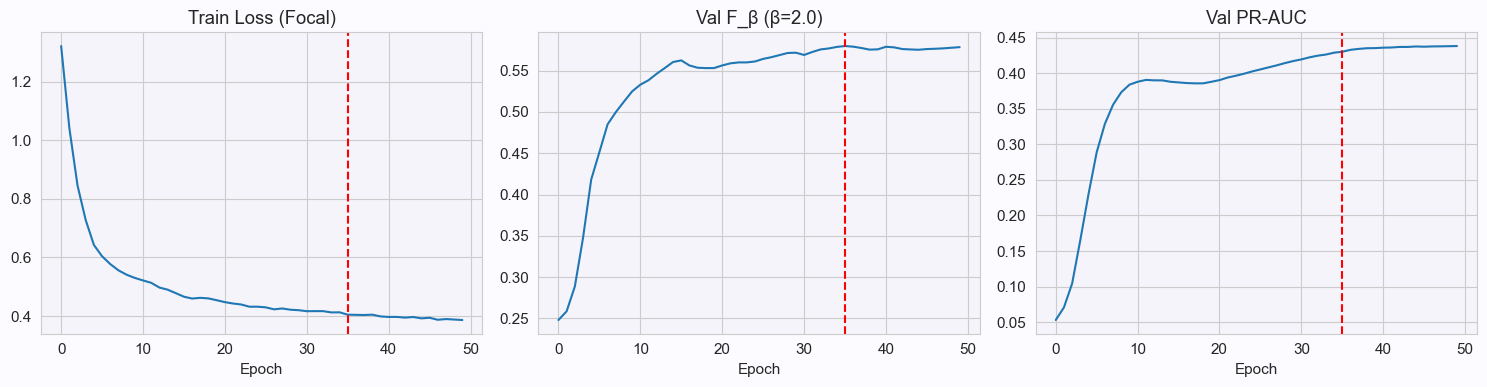

Сохранено: /Users/bolotnikovali/ИПС/figures/gnn_training_curves.png


In [7]:
if not history.get('skipped'):
    best_epoch = int(np.argmax(history['val_fbeta'])) + 1
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history['train_loss'])
    axes[0].axvline(best_epoch - 1, color='red', linestyle='--')
    axes[0].set_title('Train Loss (Focal)')
    axes[1].plot(history['val_fbeta'])
    axes[1].axvline(best_epoch - 1, color='red', linestyle='--')
    axes[1].set_title(f'Val F_β (β={BETA})')
    axes[2].plot(history['val_prauc'])
    axes[2].axvline(best_epoch - 1, color='red', linestyle='--')
    axes[2].set_title('Val PR-AUC')
    for ax in axes:
        ax.set_xlabel('Epoch')
    plt.tight_layout()
    out_fig = FIGURES_DIR / 'gnn_training_curves.png'
    plt.savefig(out_fig, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Сохранено: {out_fig}')


## 6. Экспорт скоров

In [8]:
df_scores = pd.DataFrame({'order_id': order_ids, 'gnn_fraud_prob': probs_all})
scores_path = OUTPUT_DIR / 'gnn_scores.parquet'
df_scores.to_parquet(scores_path, index=False)
print(f'Скоры сохранены: {scores_path}  ({len(df_scores):,} заказов)')
meta = json.loads((OUTPUT_DIR / 'gnn_meta.json').read_text())
print(f"best_epoch={meta['best_epoch']}  best_val_Fβ={meta['best_val_fbeta']:.4f}  hidden={meta['hidden']}")


Скоры сохранены: /Users/bolotnikovali/ИПС/outputs/gnn/ds1/gnn_scores.parquet  (4,215,398 заказов)
best_epoch=36  best_val_Fβ=0.5799  hidden=64
